# Demo: Controlled Pendulum
## Verification Master Pendulum within System

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError(
        "Could not find repo root (pyproject.toml). Set SYSSIMX_REPO_ROOT."
    )

repo_root = Path(os.environ.get("SYSSIMX_REPO_ROOT", ""))
if repo_root and repo_root.exists():
    repo_root = repo_root.resolve()
else:
    repo_root = find_repo_root(Path.cwd())
sys.path.insert(0, str(repo_root))  # .../SystemSimulation
from demos.ControlledPendulum.src.master_pendulum.components import (
    OpenSimPendulum,
    FEMPendulum,
)
from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config
from thesis.plot_setup import set_professional_style
plt = set_professional_style()

platform = sys.platform
print(platform)

linux


**Generate FMUComponents**

In [20]:
from syssimx.components.fmu import FMUComponent

demo_dir_path = Path(repo_root / "demos" / "ControlledPendulum")
package_path = Path(demo_dir_path / "MyModels/FMUs")
fmu_output_dir = package_path
fmu_output_dir = demo_dir_path / "artifacts/fmus/linux"

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

fmu_paths

{'Controllers': {'PID_Sampled': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/artifacts/fmus/linux/Controllers/PID_Sampled.fmu'),
  'PIDContinuous_cvode': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/artifacts/fmus/linux/Controllers/PIDContinuous_cvode.fmu'),
  'PIDContinuous_euler': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/artifacts/fmus/linux/Controllers/PIDContinuous_euler.fmu'),
  'PID_Continuous_cvode': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/artifacts/fmus/linux/Controllers/PID_Continuous_cvode.fmu'),
  'PID_Continuous_euler': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/artifacts/fmus/linux/Controllers/PID_Continuous_euler.fmu')},
 'Drive_QStat': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/artifacts/fmus/linux/Drive_QStat.fmu'),
 'Demo_Driven': PosixPath('/home/flo/code/SystemSimulation/demos/ControlledPendulum/artifacts/fmus/linux/De

In [21]:
ref = FMUComponent(name="ref", fmu_path=fmu_paths["Reference"], group="Input")
sensor_ref = FMUComponent(name="sensor_ref", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
sensor_state = FMUComponent(
    name="sensor_state", fmu_path=fmu_paths["AngleEncoder"], group="Sensors"
)
pid = FMUComponent(name="pid", fmu_path=fmu_paths["PID_Continuous"], group="Control")
drive = FMUComponent(name="drive", fmu_path=fmu_paths["Drive"], group="Actuator")
eqb_pendulum = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_paths["Pendulum"], group="Plant")

fmu_list = [ref, sensor_ref, sensor_state, pid, drive, eqb_pendulum]
for fmu in fmu_list:
    print(fmu.name)
    print(" Direct Feedthrough:")
    for output, inputs in fmu.direct_feedthrough.items():
        print(f"  Output: {output} <- Inputs: {inputs}")
    print()

ref
 Direct Feedthrough:
  Output: q_ref <- Inputs: set()

sensor_ref
 Direct Feedthrough:
  Output: U_q <- Inputs: set()

sensor_state
 Direct Feedthrough:
  Output: U_q <- Inputs: set()

pid
 Direct Feedthrough:
  Output: I_out <- Inputs: set()
  Output: u <- Inputs: {'ref', 'y'}

drive
 Direct Feedthrough:
  Output: torque <- Inputs: set()

EQB_Pendulum
 Direct Feedthrough:
  Output: alpha <- Inputs: {'torque'}
  Output: omega <- Inputs: set()
  Output: theta <- Inputs: set()



In [22]:
mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3  # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 2700  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = False
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'mat_params': mat_params,
    'contact_params': contact_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
    'mesh_params': mesh_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")

pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)


t = 0.0
dt = pendulum.fem.sim_params.tau
t_end = pendulum.fem.sim_params.t_end

# pendulum = pendulum.fem

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [23]:
from syssimx.system.connection import Connection

c1 = Connection(
    src_comp=ref.name,
    src_port=ref.output_specs["q_ref"].name,
    dst_comp=sensor_ref.name,
    dst_port=sensor_ref.input_specs["q"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=sensor_state.name,
    dst_port=sensor_state.input_specs["q"].name,
)

c3 = Connection(
    src_comp=sensor_ref.name,
    src_port=sensor_ref.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["ref"].name,
)

c4 = Connection(
    src_comp=sensor_state.name,
    src_port=sensor_state.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["y"].name,
)

c5 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c6 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c7 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

In [24]:
from syssimx.system.system import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

# Adding the same connection again to test validation
try:
    system.add_connection(c1)
except ValueError as e:
    print(f"Error: {e}")
system.compute_execution_order()

system.initialize(t0=0.0)

Error: Duplicate connection: ref.q_ref -> sensor_ref.q
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER       

**Create System Graph**

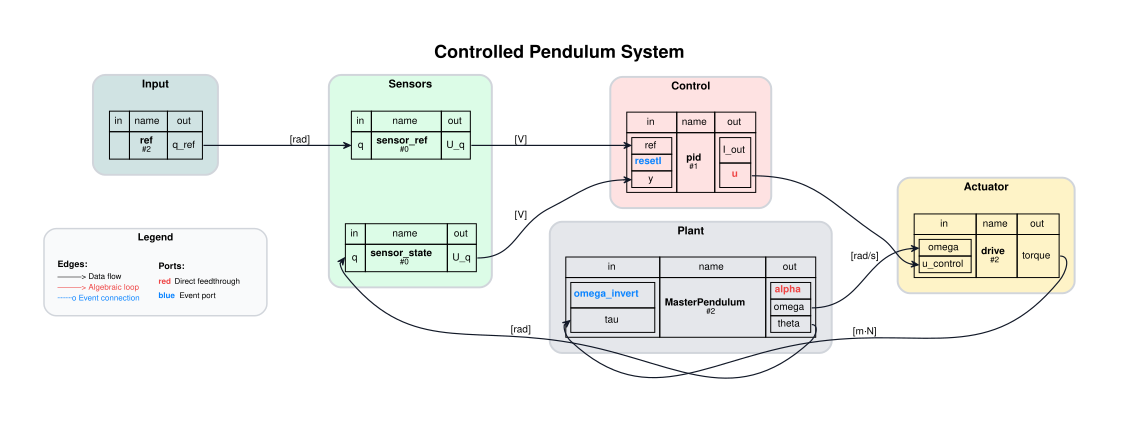

In [25]:
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [26]:
pendulum.setup_monitoring()
pendulum.display_monitoring()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [27]:
system.run(t, t_end, dt)

LOG_ASSERT        | debug   | Solving non-linear system 6 failed at time=0.02.
|                 | |       | For more information please use -lv LOG_NLS.
LOG_ASSERT        | debug   | Solving non-linear system 6 failed at time=0.02.
|                 | |       | For more information please use -lv LOG_NLS.


FMICallException: fmi2DoStep failed with status 3 (error).

In [17]:
ref_hist = ref.get_history()
t_vals_ref = ref_hist["q_ref"]["time"]
q_vals_ref = ref_hist["q_ref"]["values"]

if isinstance(pendulum, MasterPendulum):
    res_eqb = pendulum.models["FMU"].get_history()
    res_fem = pendulum.models["FEM"].get_history()
    res_os = pendulum.models["OpenSim"].get_history()

    t_vals_eqb = res_eqb["theta"]["time"]
    q_vals_eqb = res_eqb["theta"]["values"]
    omega_vals_eqb = res_eqb["omega"]["values"]
    alpha_vals_eqb = res_eqb["alpha"]["values"]

    t_vals_fem = res_fem["theta"]["time"]
    q_vals_fem = res_fem["theta"]["values"]
    omega_vals_fem = res_fem["omega"]["values"]
    alpha_vals_fem = res_fem["alpha"]["values"]

    t_vals_os = res_os["theta"]["time"]
    q_vals_os = res_os["theta"]["values"]
    omega_vals_os = res_os["omega"]["values"]
    alpha_vals_os = res_os["alpha"]["values"]

if isinstance(pendulum, FMUComponent):
    pendulum_hist = pendulum.get_history()
    t_vals_eqb = pendulum_hist["theta"]["time"]
    q_vals_eqb = pendulum_hist["theta"]["values"]
    omega_vals_eqb = pendulum_hist["omega"]["values"]
    alpha_vals_eqb = pendulum_hist["alpha"]["values"]

# Drive torque
drive_hist = drive.get_history()
t_drive = drive_hist["torque"]["time"]
torque_drive_vals = drive_hist["torque"]["values"]

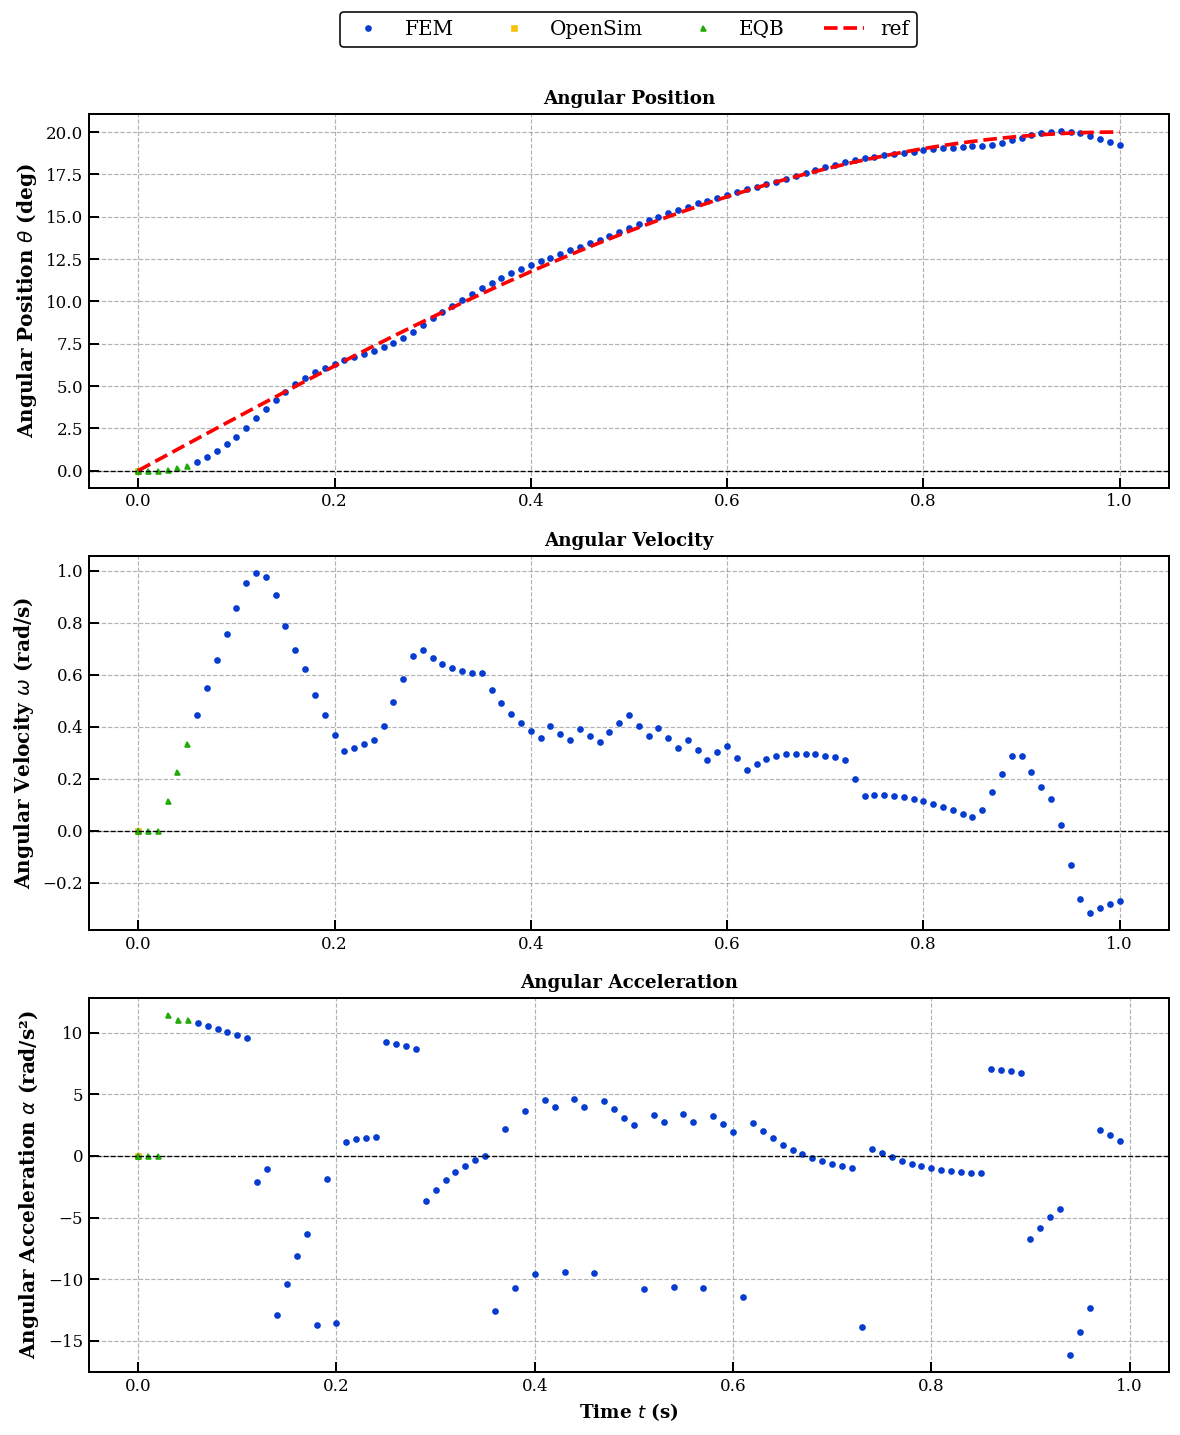

In [18]:
marker_size = 3
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
}  # Deep blue
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}  # Green
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}  # Purple
fontdict = {"fontsize": 11, "fontweight": "bold"}

plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1).set_title("Angular Position", **fontdict)
plt.plot(t_vals_fem, np.rad2deg(q_vals_fem), label="FEM", **fem_style)
plt.plot(t_vals_os, np.rad2deg(q_vals_os), label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, np.rad2deg(q_vals_eqb), label="EQB", **eqb_style)
plt.plot(t_vals_ref, np.rad2deg(q_vals_ref), label="ref", color="red", linestyle="--")
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel(r"Angular Position $\theta$ (deg)", fontweight="bold")
plt.grid(which="both")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=4)


plt.subplot(3, 1, 2).set_title("Angular Velocity", **fontdict)
plt.plot(t_vals_fem, omega_vals_fem, label="FEM", **fem_style)
plt.plot(t_vals_os, omega_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, omega_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel(r"Angular Velocity $\omega$ (rad/s)", fontweight="bold")
plt.grid(which="both")

plt.subplot(3, 1, 3).set_title("Angular Acceleration", **fontdict)
plt.plot(t_vals_fem[:-1], alpha_vals_fem[:-1], label="FEM", **fem_style)
plt.plot(t_vals_os, alpha_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, alpha_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel(r"Angular Acceleration $\alpha$ (rad/s²)", fontweight="bold")
plt.grid(which="both")

plt.xlabel("Time $t$ (s)", **fontdict)
plt.tight_layout()
# plt.savefig("figures/System_MasterPendulum.svg")
plt.show()

In [101]:
target_hist = set_point.get_history()
fmu_hist = pendulum.get_history()

In [102]:
# target_hist = set_point.get_history()
# fmu_hist = pendulum.fmu.get_history()
# opensim_hist = pendulum.opensim.get_history()
# fem_hist = pendulum.fem.get_history()

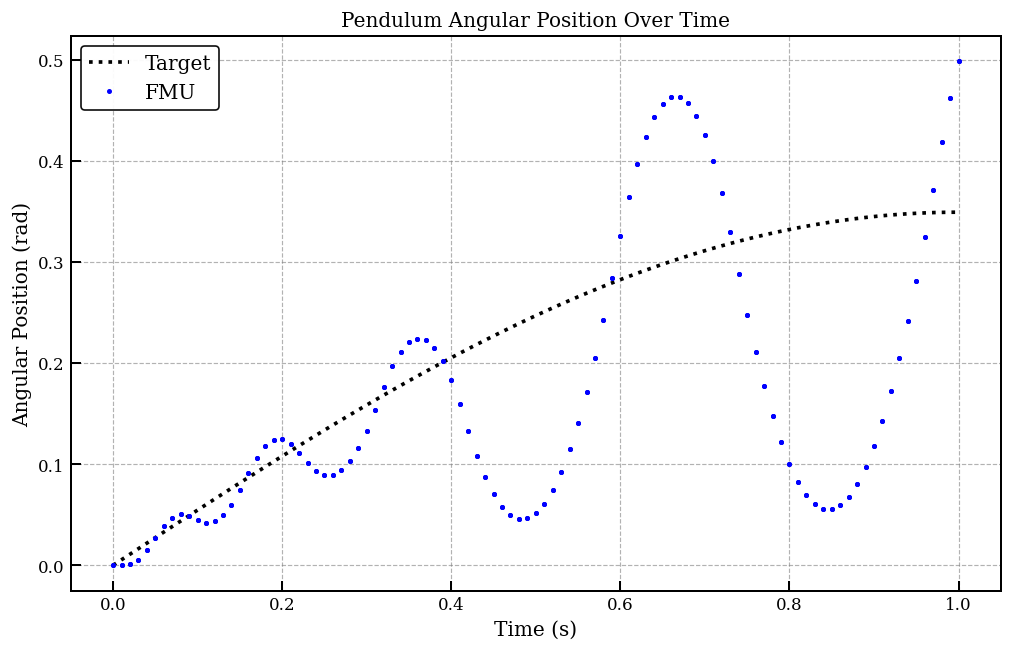

In [103]:
t_target = target_hist["theta_ref"]["time"]
theta_target = target_hist["theta_ref"]["values"]

t_fmu = fmu_hist['theta']['time']
theta_fmu = fmu_hist['theta']['values']

# t_opensim = opensim_hist['theta']['time']
# theta_opensim = opensim_hist['theta']['values']

# t_fem = fem_hist['theta']['time']
# theta_fem = fem_hist['theta']['values']

marker_size = 2

plt.figure(figsize=(10, 6))
plt.plot(t_target, theta_target, label='Target', linestyle=':', color='black', markersize=marker_size)
plt.plot(t_fmu, theta_fmu, label='FMU', linestyle='None', marker='o', color='blue', markersize=marker_size)
# plt.plot(t_opensim, theta_opensim, label='OpenSim', linestyle='None', marker='s', color='green', markersize=marker_size)
# plt.plot(t_fem, theta_fem, label='FEM', linestyle='None', marker='^', color='red', markersize=marker_size)
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (rad)')
plt.title('Pendulum Angular Position Over Time')
plt.legend()
plt.grid()
plt.show()

In [104]:
ref_hist = set_point.get_history()
t_vals_ref = ref_hist["q_ref"]["time"]
theta_vals_ref = ref_hist["q_ref"]["values"]

if isinstance(pendulum, MasterPendulum):
    res_eqb = pendulum.models["FMU"].get_history()
    res_fem = pendulum.models["FEM"].get_history()
    res_os = pendulum.models["OpenSim"].get_history()

    t_vals_eqb = res_eqb["q"]["time"]
    q_vals_eqb = res_eqb["q"]["values"]
    omega_vals_eqb = res_eqb["omega"]["values"]
    alpha_vals_eqb = res_eqb["alpha"]["values"]

    t_vals_fem = res_fem["q"]["time"]
    q_vals_fem = res_fem["q"]["values"]
    omega_vals_fem = res_fem["omega"]["values"]
    alpha_vals_fem = res_fem["alpha"]["values"]

    t_vals_os = res_os["q"]["time"]
    q_vals_os = res_os["q"]["values"]
    omega_vals_os = res_os["omega"]["values"]
    alpha_vals_os = res_os["alpha"]["values"]

if isinstance(pendulum, FMUComponent):
    pendulum_hist = pendulum.get_history()
    t_vals_eqb = pendulum_hist["q"]["time"]
    q_vals_eqb = pendulum_hist["q"]["values"]
    omega_vals_eqb = pendulum_hist["omega"]["values"]
    alpha_vals_eqb = pendulum_hist["alpha"]["values"]

# Drive torque
drive_hist = drive.get_history()
t_drive = drive_hist["torque"]["time"]
torque_drive_vals = drive_hist["torque"]["values"]

KeyError: 'q_ref'

NameError: name 't_vals_fem' is not defined

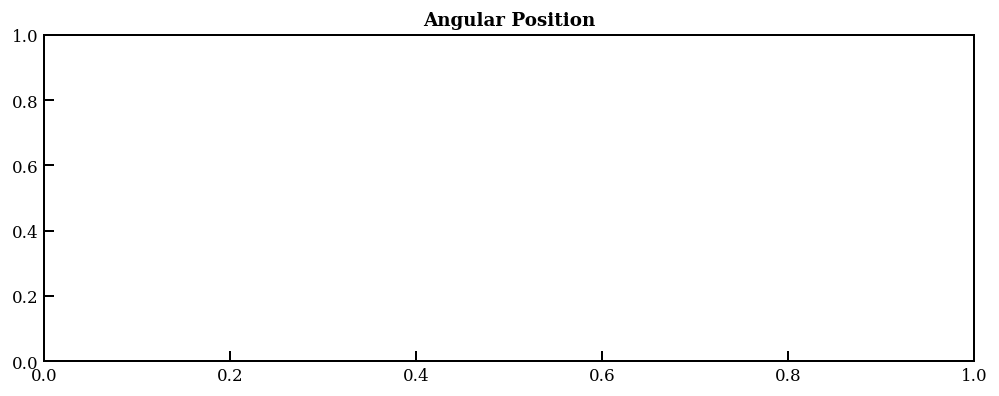

In [ ]:
marker_size = 3
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
}  # Deep blue
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}  # Green
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}  # Purple
fontdict = {"fontsize": 11, "fontweight": "bold"}

plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1).set_title("Angular Position", **fontdict)
plt.plot(t_vals_fem, np.rad2deg(q_vals_fem), label="FEM", **fem_style)
plt.plot(t_vals_os, np.rad2deg(q_vals_os), label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, np.rad2deg(q_vals_eqb), label="EQB", **eqb_style)
plt.plot(t_vals_ref, np.rad2deg(theta_vals_ref), label="ref", color="red", linestyle="--")
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel(r"Angular Position $\theta$ (deg)", fontweight="bold")
plt.grid(which="both")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=4)


plt.subplot(3, 1, 2).set_title("Angular Velocity", **fontdict)
plt.plot(t_vals_fem, omega_vals_fem, label="FEM", **fem_style)
plt.plot(t_vals_os, omega_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, omega_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel(r"Angular Velocity $\omega$ (rad/s)", fontweight="bold")
plt.grid(which="both")

plt.subplot(3, 1, 3).set_title("Angular Acceleration", **fontdict)
plt.plot(t_vals_fem[:-1], alpha_vals_fem[:-1], label="FEM", **fem_style)
plt.plot(t_vals_os, alpha_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, alpha_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel(r"Angular Acceleration $\alpha$ (rad/s²)", fontweight="bold")
plt.grid(which="both")

plt.xlabel("Time $t$ (s)", **fontdict)
plt.tight_layout()
# plt.savefig("figures/System_MasterPendulum.svg")
plt.show()